## 环境配置
### 安装配置 R 语言环境

```
## 进入 R 编程环境
conda activate LabelTransfer

## 安装所需库
conda create -n LabelTransfer -c conda-forge \
r-base=4.3 \
hdf5 \
r-hdf5r \
r-seurat \
r-seuratobject \
r-arrow \
r-tidyverse \
r-ggplot2 \
r-ggpmisc \
r-cowplot \
r-gridextra \
r-viridis \
r-hrbrthemes \
r-jsonlite \
r-remotes
```

### 安装BPcells

```
## 下载 BPcells 包
cd ~
git clone https://github.com/bnprks/BPCells.git

## 进入 R 环境
R

## 使用本地编译安装
remotes::install_local("~/BPCells/r")
```

### 安装 ipynb 文件运行 R 所需库

```
## 安装所需库
conda install -c conda-forge \
r-irkernel \
jupyter \
notebook \
ipykernel

## 进入 R 注册 kernel
IRkernel::installspec(name = "LabelTransfer", displayname = "R_LabelTransfer")

##  数据准备

### 在终端中执行，进入你的工作目录

```
cd ./data/
wget https://s3-us-west-2.amazonaws.com/10x.files/samples/xenium/3.0.0/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs.zip
unzip Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs.zip
```

```
curl -O https://cf.10xgenomics.com/samples/cell-exp/8.0.1/17k_Ovarian_Cancer_scFFPE/17k_Ovarian_Cancer_scFFPE_count_filtered_feature_bc_matrix.h5
```

```
curl -O https://cf.10xgenomics.com/supp/cell-exp/FLEX_Ovarian_Barcode_Cluster_Annotation.csv
```

In [1]:
# ============================================
# Cell 1: 统一初始化 - 集中管理所有配置
# ============================================

# 1. 设置工作目录
setwd("/home/ailab/caohao/AdaDiss/")

# 2. 定义所有文件路径
paths <- list(
    # Flex 数据
    flex_h5 = "./data/17k_Ovarian_Cancer_scFFPE_count_filtered_feature_bc_matrix.h5",
    flex_annotation = "./data/FLEX_Ovarian_Barcode_Cluster_Annotation.csv",
    flex_bpcells_dir = "./data/flex_counts_bpcells/",
    flex_cache = "./data/flex_data_processed.rds",
    
    # Xenium 数据
    xenium_dir = "./data/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs/",
    xenium_bpcells_dir = "./data/xenium_counts_bpcells/",
    xenium_cache = "./data/xenium_data_processed.rds",
    xenium_gene_panel = "./data/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs/gene_panel.json",
    
    # 输出文件
    output_csv = "./cell_groups.csv"
)

# 3. 设置分析参数
params <- list(
    # Flex QC 参数
    flex_min_counts = 200,
    flex_max_counts = 10000,
    flex_max_mt = 10,
    
    # Xenium 参数
    xenium_npcs = 50,
    xenium_dims = 1:30,
    xenium_resolution = 0.6,
    xenium_cluster_name = "clusters",
    
    # 标签转移参数
    transfer_dims = 1:30,
    transfer_k = 50,
    
    # 可视化参数
    seed = 42
)

# 4. 设置随机种子
set.seed(params$seed)

# 5. 加载所有必要的包
cat("📦 加载R包...\n")
suppressPackageStartupMessages({
    # 核心包
    library(Seurat)
    library(BPCells)
    library(SeuratObject)
    library(SeuratDisk)
    library(tidyverse)
    library(jsonlite)
    
    # 绘图包
    library(ggplot2)
    library(ggpmisc)
    library(scales)
    library(cowplot)
    library(gridExtra)
    library(viridis)
    library(hrbrthemes)
})

# 6. 设置Seurat内存限制
options(future.globals.maxSize = 1e9)

# 7. 定义缓存加载函数
load_or_process <- function(cache_file, process_func, force_reprocess = FALSE) {
    if (!force_reprocess && file.exists(cache_file)) {
        cat("📦 从缓存加载:", basename(cache_file), "\n")
        return(readRDS(cache_file))
    } else {
        if (force_reprocess) cat("🔄 强制重新处理...\n")
        else cat("🔄 首次运行，正在处理...\n")
        obj <- process_func()
        saveRDS(obj, cache_file)
        cat("✅ 已保存到:", basename(cache_file), "\n")
        return(obj)
    }
}

# 8. 打印配置信息
cat("\n✅ 环境初始化完成\n")
cat("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n")
cat("📁 工作目录:", getwd(), "\n")
cat("📊 Flex缓存:", paths$flex_cache, "\n")
cat("📊 Xenium缓存:", paths$xenium_cache, "\n")
cat("📤 输出文件:", paths$output_csv, "\n")
cat("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n\n")

📦 加载R包...


Warning message:
“package ‘BPCells’ was built under R version 4.5.2”
Warning message:
“package ‘SeuratDisk’ was built under R version 4.5.2”



✅ 环境初始化完成
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📁 工作目录: /home/ailab/caohao/AdaDiss 
📊 Flex缓存: ./data/flex_data_processed.rds 
📊 Xenium缓存: ./data/xenium_data_processed.rds 
📤 输出文件: ./cell_groups.csv 
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



In [2]:
# ============================================
# Cell 2: 加载Flex参考数据（带缓存机制）
# ============================================

process_flex_data <- function() {
    cat("  步骤1: 加载原始数据...\n")
    flex_obj <- Read10X_h5(paths$flex_h5) %>% CreateSeuratObject()
    
    cat("  步骤2: 配置BPCells磁盘存储...\n")
    if (!dir.exists(paths$flex_bpcells_dir)) {
        write_matrix_dir(mat = flex_obj[["RNA"]]$counts, dir = paths$flex_bpcells_dir)
    }
    flex_obj[['RNA']]$counts <- open_matrix_dir(dir = paths$flex_bpcells_dir)
    
    cat("  步骤3: 计算线粒体比例...\n")
    flex_obj[["percent.mt"]] <- PercentageFeatureSet(flex_obj, pattern = "^MT-")
    
    cat("  步骤4: QC过滤...\n")
    n_before <- ncol(flex_obj)
    flex_obj <- subset(flex_obj, 
                       subset = nCount_RNA > params$flex_min_counts & 
                                nCount_RNA < params$flex_max_counts & 
                                percent.mt < params$flex_max_mt)
    cat("    过滤前:", n_before, "细胞 → 过滤后:", ncol(flex_obj), "细胞\n")
    
    cat("  步骤5: 添加细胞类型注释...\n")
    if (file.exists(paths$flex_annotation)) {
        ann_df <- read.csv(paths$flex_annotation)
        cell_types <- setNames(ann_df$Cell.Annotation, ann_df$Barcode)
        # 只保留当前数据中存在的细胞
        cell_types <- cell_types[names(cell_types) %in% colnames(flex_obj)]
        flex_obj <- AddMetaData(flex_obj, cell_types[colnames(flex_obj)], "cell_type")
        cat("    注释了", length(unique(flex_obj$cell_type)), "种细胞类型\n")
    } else {
        warning("找不到注释文件: ", paths$flex_annotation)
    }
    
    return(flex_obj)
}

# 加载或处理Flex数据
flex_data.obj <- load_or_process(paths$flex_cache, process_flex_data)

cat("\n📊 Flex数据摘要:\n")
cat("  - 细胞数量:", ncol(flex_data.obj), "\n")
cat("  - 基因数量:", nrow(flex_data.obj), "\n")
cat("  - 细胞类型:", length(unique(flex_data.obj$cell_type)), "\n")

🔄 首次运行，正在处理...
  步骤1: 加载原始数据...
  步骤2: 配置BPCells磁盘存储...
  步骤3: 计算线粒体比例...
  步骤4: QC过滤...
    过滤前: 17553 细胞 → 过滤后: 17050 细胞
  步骤5: 添加细胞类型注释...
    注释了 16 种细胞类型
✅ 已保存到: flex_data_processed.rds 

📊 Flex数据摘要:
  - 细胞数量: 17050 
  - 基因数量: 18082 
  - 细胞类型: 16 


In [3]:
# ============================================
# Cell 3: 加载Xenium数据（带缓存机制）
# ============================================

process_xenium_data <- function() {
    cat("  步骤1: 加载原始数据...\n")
    xenium_obj <- LoadXenium(paths$xenium_dir, fov = "fov", molecule.coordinates = FALSE)
    DefaultAssay(xenium_obj) <- "Xenium"
    
    cat("  步骤2: 配置BPCells磁盘存储...\n")
    if (!dir.exists(paths$xenium_bpcells_dir)) {
        write_matrix_dir(mat = xenium_obj[["Xenium"]]$counts, dir = paths$xenium_bpcells_dir)
    }
    xenium_obj[['Xenium']]$counts <- open_matrix_dir(dir = paths$xenium_bpcells_dir)
    
    cat("  步骤3: 过滤空细胞...\n")
    n_before <- ncol(xenium_obj)
    xenium_obj <- subset(xenium_obj, subset = nCount_Xenium > 0)
    cat("    过滤前:", n_before, "细胞 → 过滤后:", ncol(xenium_obj), "细胞\n")
    
    cat("  步骤4: 添加log转换元数据...\n")
    xenium_obj@meta.data$nCount_Xenium_log <- log1p(xenium_obj@meta.data$nCount_Xenium)
    xenium_obj@meta.data$nFeature_Xenium_log <- log1p(xenium_obj@meta.data$nFeature_Xenium)
    
    return(xenium_obj)
}

# 加载或处理Xenium数据
xenium.obj <- load_or_process(paths$xenium_cache, process_xenium_data)

cat("\n📊 Xenium数据摘要:\n")
cat("  - 细胞数量:", ncol(xenium.obj), "\n")
cat("  - 基因数量:", nrow(xenium.obj), "\n")

🔄 首次运行，正在处理...
  步骤1: 加载原始数据...


Genome matrix has multiple modalities, returning a list of matrices for this genome

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


  步骤2: 配置BPCells磁盘存储...
  步骤3: 过滤空细胞...


Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”


    过滤前: 407124 细胞 → 过滤后: 406611 细胞
  步骤4: 添加log转换元数据...
✅ 已保存到: xenium_data_processed.rds 

📊 Xenium数据摘要:
  - 细胞数量: 406611 
  - 基因数量: 5101 


📈 计算基因表达相关性...


Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 41 rows containing non-finite outside the scale range
(`stat_poly_eq()`).”


✅ 相关性分析完成


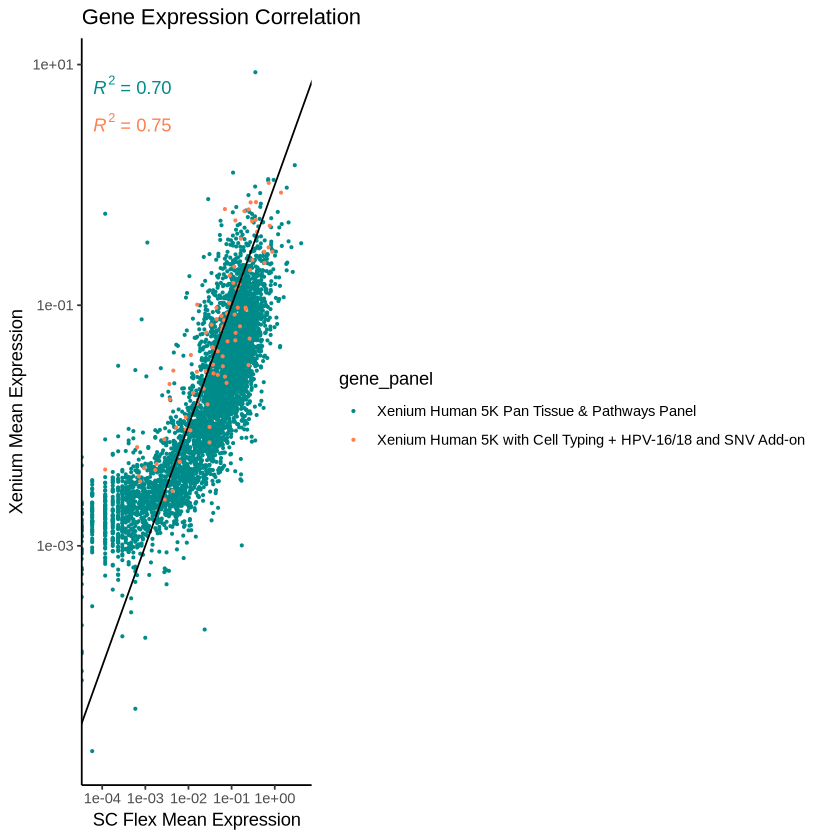

In [4]:
# ============================================
# Cell 4: 基因表达相关性分析（可选，如失败可跳过）
# ============================================

if (file.exists(paths$xenium_gene_panel)) {
    cat("📈 计算基因表达相关性...\n")
    
    # 定义函数
    get_gex_means <- function(xenium_obj, flex_obj) {
        xen_means <- data.frame(
            mean_counts = rowMeans(xenium_obj[["Xenium"]]$counts),
            gene = rownames(xenium_obj[["Xenium"]]$counts)
        ) %>% arrange(desc(mean_counts)) %>% mutate(Rank = 1:n())
        
        flex_means <- data.frame(
            mean_counts = rowMeans(flex_obj[["RNA"]]$counts),
            gene = rownames(flex_obj[["RNA"]]$counts)
        ) %>% arrange(desc(mean_counts)) %>% mutate(Rank = 1:n())
        
        return(merge(xen_means, flex_means, by.x = "gene", by.y = "gene", all.x = TRUE))
    }
    
    # 读取基因面板
    gene_panel <- fromJSON(paths$xenium_gene_panel)
    targets <- gene_panel$payload$targets
    panel_source <- setNames(
        data.frame(cbind(targets$source$identity$name, targets$type$data$name)), 
        c("gene_panel", "gene")
    )
    
    # 合并数据
    merged_means <- get_gex_means(xenium.obj, flex_data.obj)
    merged_means <- merge(merged_means, panel_source, by.x = "gene", by.y = "gene", all.x = TRUE) %>%
                   na.omit() %>% arrange(gene_panel)
    
    # 绘图
    p_cor <- ggplot(merged_means, aes(x = mean_counts.y, y = mean_counts.x, color = gene_panel)) +
        geom_point(size = 0.5) +
        scale_colour_manual(values = c("darkcyan", "coral")) +
        stat_poly_eq() +
        scale_x_log10() + scale_y_log10() +
        xlab("SC Flex Mean Expression") + ylab("Xenium Mean Expression") +
        ggtitle("Gene Expression Correlation") +
        theme_classic() +
        geom_abline(slope = 1, intercept = 0)
    
    print(p_cor)
    cat("✅ 相关性分析完成\n")
} else {
    cat("⚠️ 跳过相关性分析（找不到gene_panel.json）\n")
}

🔧 处理Flex参考数据...


Normalizing layer: counts

Finding variable features for layer counts

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 17050
Number of edges: 598740

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9287
Number of communities: 17
Elapsed time: 5 seconds
✅ Flex数据处理完成


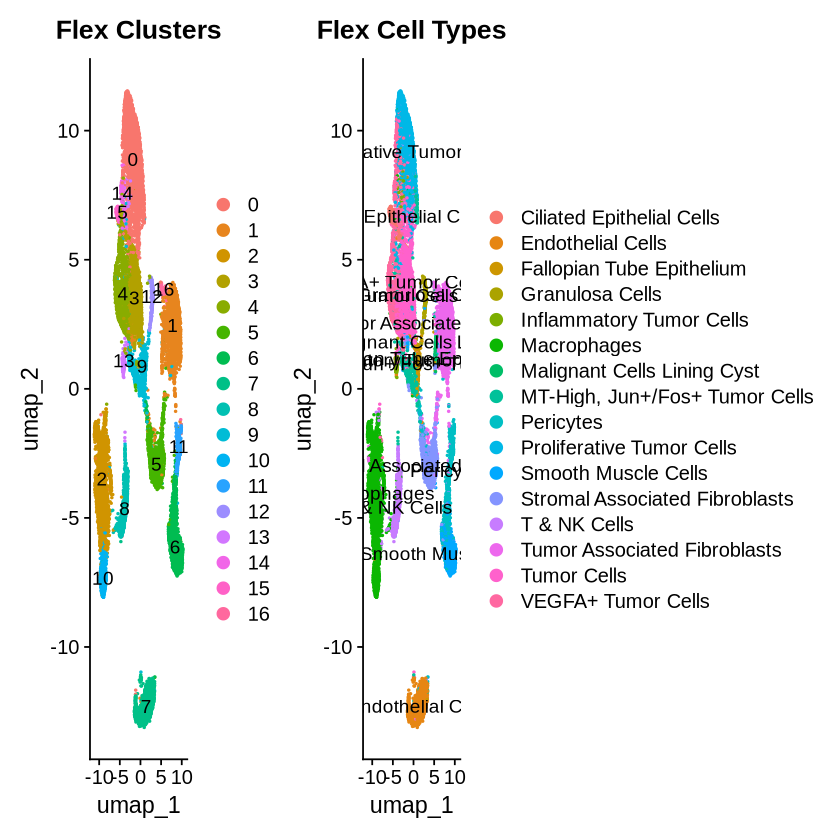

In [5]:
# ============================================
# Cell 5: Flex参考数据处理
# ============================================

cat("🔧 处理Flex参考数据...\n")

DefaultAssay(flex_data.obj) <- "RNA"
flex_data.obj <- NormalizeData(flex_data.obj) %>%
                 FindVariableFeatures() %>%
                 ScaleData() %>%
                 RunPCA(verbose = FALSE) %>%
                 RunUMAP(dims = 1:15, verbose = FALSE) %>%
                 FindNeighbors(dims = 1:15) %>%
                 FindClusters(resolution = 0.5)

# 可视化
p1 <- DimPlot(flex_data.obj, reduction = "umap", group.by = "RNA_snn_res.0.5", 
              label = TRUE, pt.size = 0.2) + ggtitle("Flex Clusters")
p2 <- DimPlot(flex_data.obj, reduction = "umap", group.by = "cell_type", 
              label = TRUE, pt.size = 0.2) + ggtitle("Flex Cell Types")

# 显示
print(p1 + p2)

cat("✅ Flex数据处理完成\n")

🔧 处理Xenium数据（细胞数: 406611 ）


Normalizing layer: counts

Finding variable features for layer counts

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 406611
Number of edges: 10966759

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8390
Number of communities: 54
Elapsed time: 995 seconds


35 singletons identified. 19 final clusters.

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



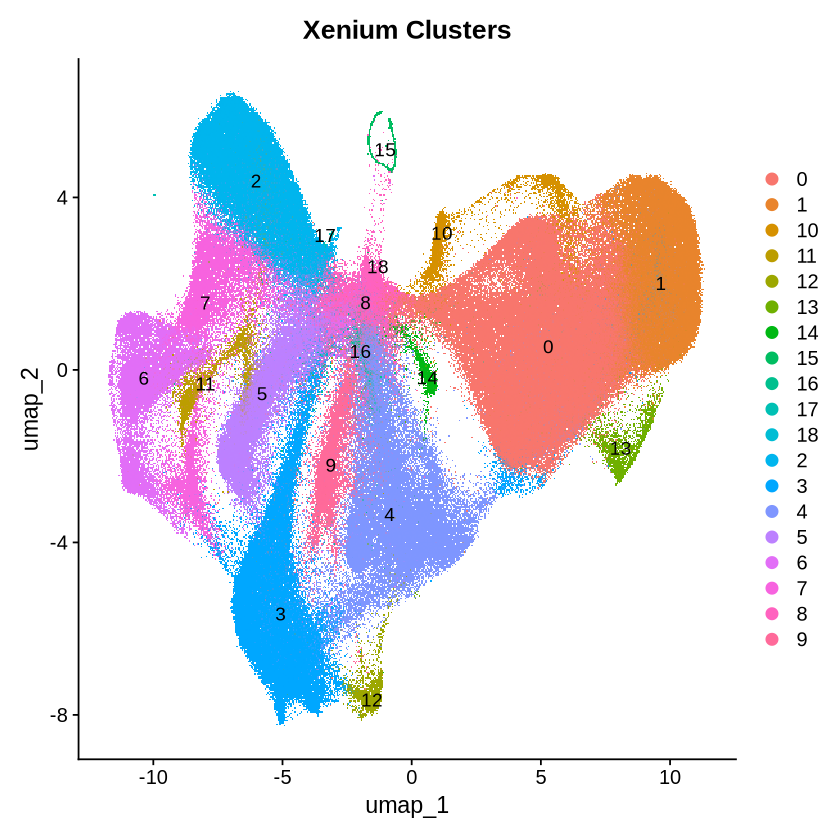


聚类统计:

     0      1     10     11     12     13     14     15     16     17     18 
115241  49668   5871   3918   2822   2407   2292   1413   1338     96      2 
     2      3      4      5      6      7      8      9 
 48217  44897  40881  27423  20900  16971  11536  10718 
✅ Xenium数据处理完成


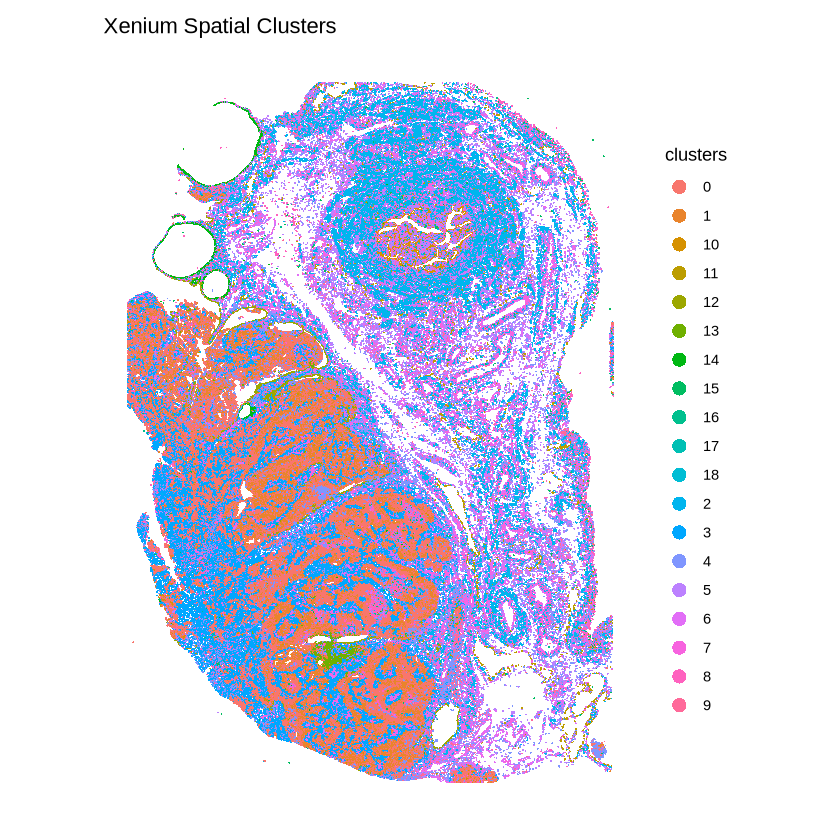

In [6]:
# ============================================
# Cell 6: Xenium数据降维和聚类
# ============================================

cat("🔧 处理Xenium数据（细胞数:", ncol(xenium.obj), "）\n")

DefaultAssay(xenium.obj) <- "Xenium"

xenium.obj <- NormalizeData(xenium.obj) %>%
              FindVariableFeatures() %>%
              ScaleData() %>%
              RunPCA(npcs = params$xenium_npcs, verbose = FALSE) %>%
              RunUMAP(dims = params$xenium_dims, verbose = FALSE) %>%
              FindNeighbors(reduction = "pca", dims = params$xenium_dims) %>%
              FindClusters(resolution = params$xenium_resolution, 
                          cluster.name = params$xenium_cluster_name)

# 可视化
p3 <- DimPlot(xenium.obj, group.by = params$xenium_cluster_name, label = TRUE) + 
      ggtitle("Xenium Clusters")
print(p3)

p4 <- ImageDimPlot(xenium.obj, fov = "fov", group.by = params$xenium_cluster_name, 
                   size = 0.5, dark.background = FALSE) +
      ggtitle("Xenium Spatial Clusters")
print(p4)

# 统计
cat("\n聚类统计:\n")
print(table(xenium.obj$clusters))

cat("✅ Xenium数据处理完成\n")

In [7]:
# ============================================
# Cell 7: 标签转移（核心步骤）
# ============================================

# 检查是否已经完成标签转移
if (!"predicted.id" %in% colnames(xenium.obj@meta.data) || 
    !"predicted.id_full" %in% colnames(xenium.obj@meta.data)) {
    
    cat("🏷️  开始标签转移...\n")
    
    # 获取共同基因
    flex_xen_common_genes <- intersect(rownames(xenium.obj), rownames(flex_data.obj))
    cat("  共同基因数量:", length(flex_xen_common_genes), "\n")
    
    if (length(flex_xen_common_genes) < 100) {
        warning("共同基因数量较少（<100），标签转移效果可能不佳")
    }
    
    # 创建Flex子集
    cat("  创建Flex子集...\n")
    flex_subset <- CreateSeuratObject(
        counts = flex_data.obj[["RNA"]]$counts[flex_xen_common_genes,],
        meta = flex_data.obj@meta.data
    ) %>%
        NormalizeData() %>%
        FindVariableFeatures() %>%
        ScaleData() %>%
        RunPCA(verbose = FALSE)
    
    # 将counts转回内存格式
    cat("  准备数据...\n")
    flex_data.obj[["RNA"]]$counts <- as(flex_data.obj[["RNA"]]$counts, "dgCMatrix")
    xenium.obj[["Xenium"]]$counts <- as(xenium.obj[["Xenium"]]$counts, "dgCMatrix")
    
    # 寻找锚点
    cat("  寻找锚点（这可能需要一些时间）...\n")
    anchors_from_flex <- FindTransferAnchors(
        reference = flex_subset,
        query = xenium.obj,
        features = flex_xen_common_genes,
        dims = params$transfer_dims,
        reference.reduction = "pca"
    )
    
    # 转移标签
    cat("  转移标签...\n")
    label_transfer <- TransferData(
        anchorset = anchors_from_flex,
        refdata = flex_subset$cell_type,
        dims = params$transfer_dims
    )
    
    # 添加预测结果
    xenium.obj <- AddMetaData(xenium.obj, metadata = label_transfer, col.name = 'predicted.id')
    
    # 也保存到完整标签列
    xenium.obj@meta.data$predicted.id_full <- xenium.obj@meta.data$predicted.id
    xenium.obj@meta.data$predicted.id_full.score <- xenium.obj@meta.data$predicted.id.score
    
    cat("✅ 标签转移完成\n")
    cat("\n预测细胞类型分布:\n")
    print(table(xenium.obj$predicted.id))
    
} else {
    cat("✅ 标签转移结果已存在，跳过\n")
}

🏷️  开始标签转移...
  共同基因数量: 4912 
  创建Flex子集...


Normalizing layer: counts

Finding variable features for layer counts



  准备数据...
  寻找锚点（这可能需要一些时间）...


Projecting cell embeddings

Finding neighborhoods

Finding anchors

	Found 30971 anchors



  转移标签...


Finding integration vectors

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Finding integration vector weights

Predicting cell labels



✅ 标签转移完成

预测细胞类型分布:

     Ciliated Epithelial Cells              Endothelial Cells 
                          1476                          20252 
     Fallopian Tube Epithelium                Granulosa Cells 
                          2998                           1882 
      Inflammatory Tumor Cells                    Macrophages 
                          1402                          27999 
   Malignant Cells Lining Cyst MT-High, Jun+/Fos+ Tumor Cells 
                          2076                          85348 
                     Pericytes      Proliferative Tumor Cells 
                         19431                          15948 
           Smooth Muscle Cells Stromal Associated Fibroblasts 
                         48419                          24975 
                  T & NK Cells   Tumor Associated Fibroblasts 
                         12831                          48640 
                   Tumor Cells             VEGFA+ Tumor Cells 
                         27550    

📊 绘制预测结果...


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



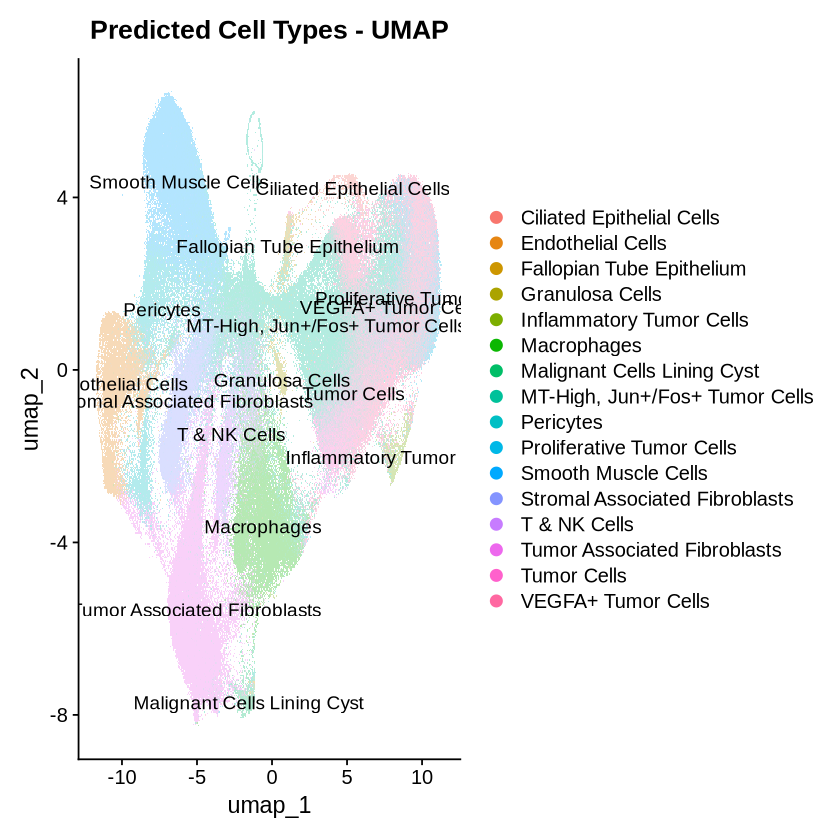

ERROR: [1m[33mError[39m in `geom_violin()`:[22m
[1m[22m[33m![39m Problem while computing aesthetics.
[36mℹ[39m Error occurred in the 1st layer.
[1mCaused by error:[22m
[33m![39m object 'predicted.id.score' not found


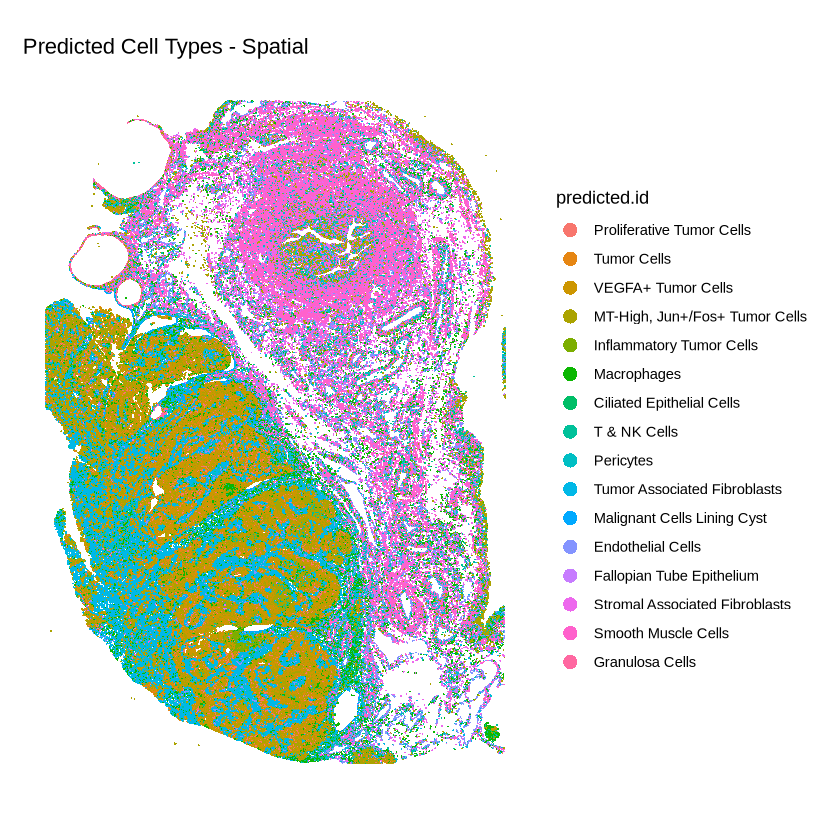

In [8]:
# ============================================
# Cell 8: 可视化标签转移结果
# ============================================

if ("predicted.id" %in% colnames(xenium.obj@meta.data)) {
    
    # 获取实际出现的细胞类型
    present_types <- unique(xenium.obj$predicted.id)
    
    cat("📊 绘制预测结果...\n")
    
    # UMAP可视化
    p5 <- DimPlot(xenium.obj, reduction = "umap", group.by = "predicted.id", 
                  label = TRUE, pt.size = 0.3) + 
          ggtitle("Predicted Cell Types - UMAP")
    print(p5)
    
    # 空间可视化
    p6 <- ImageDimPlot(xenium.obj, fov = "fov", group.by = "predicted.id", 
                       size = 0.5, dark.background = FALSE) +
          ggtitle("Predicted Cell Types - Spatial")
    print(p6)
    
    # 预测分数分布
    p7 <- xenium.obj@meta.data %>%
        ggplot(aes(x = predicted.id, y = predicted.id.score, fill = predicted.id)) +
        geom_violin(scale = "width") +
        scale_fill_viridis_d(alpha = 0.6) +
        theme_minimal() +
        theme(legend.position = "none",
              axis.text.x = element_text(angle = 45, hjust = 1)) +
        ggtitle("Prediction Scores by Cell Type") +
        xlab("") + ylab("Score") +
        ylim(0, 1)
    print(p7)
    
    cat("✅ 可视化完成\n")
} else {
    cat("⚠️ 未找到预测结果，请先运行Cell 7\n")
}

In [ ]:
# ============================================
# Cell 9: 导出结果
# ============================================

if ("predicted.id" %in% colnames(xenium.obj@meta.data)) {
    
    # 准备导出数据
    cell_groups <- xenium.obj@meta.data %>%
        rownames_to_column(var = "cell_id") %>%
        select(cell_id, 
               cluster = all_of(params$xenium_cluster_name),
               predicted_cell_type = predicted.id,
               prediction_score = predicted.id.score)
    
    # 写入CSV
    write.csv(cell_groups, paths$output_csv, row.names = FALSE)
    
    cat("✅ 结果已导出到:", paths$output_csv, "\n")
    cat("\n文件预览:\n")
    print(head(cell_groups, 10))
    
    # 保存最终对象
    saveRDS(xenium.obj, "./data/xenium_annotated_final.rds")
    cat("✅ 完整Seurat对象已保存: ./data/xenium_annotated_final.rds\n")
    
} else {
    cat("⚠️ 未找到预测结果，请先运行Cell 7\n")
}